In [1]:
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

In [2]:
mpl.rcParams['font.family'] = 'Malgun Gothic'  # Windows
mpl.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [3]:
data_path = "../../data/raw/T-Fillet/TF031_060"
TF_case = "TF033"
TF_Pass = f"{TF_case}_1PASS"

pkl_path = f"{data_path}/{TF_case}/{TF_Pass}/{TF_case}_FLIR.pkl"

In [4]:
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

print(data.keys())

dict_keys([1776383706.1233826, 1776383706.1421702, 1776383706.1570394, 1776383706.1755092, 1776383706.1835139, 1776383706.1921933, 1776383706.2002158, 1776383706.2049298, 1776383706.226315, 1776383706.2333457, 1776383706.2550247, 1776383706.304978, 1776383706.34724, 1776383706.3874128, 1776383706.427295, 1776383706.4550235, 1776383706.5063453, 1776383706.547328, 1776383706.5860033, 1776383706.623745, 1776383706.6619642, 1776383706.7054784, 1776383706.7469127, 1776383706.7729146, 1776383706.8223095, 1776383706.8557496, 1776383706.9056642, 1776383706.9391584, 1776383706.9725869, 1776383707.0222619, 1776383707.056287, 1776383707.1058025, 1776383707.139098, 1776383707.1858022, 1776383707.2265935, 1776383707.2557092, 1776383707.3080692, 1776383707.3471045, 1776383707.3871577, 1776383707.4273129, 1776383707.4672074, 1776383707.5072327, 1776383707.54698, 1776383707.587208, 1776383707.6272142, 1776383707.6674905, 1776383707.7085931, 1776383707.7480216, 1776383707.7871864, 1776383707.8273003, 1

In [22]:
# 3. 딕셔너리에서 5개의 키(타임스텝) 추출
keys = list(data.keys())
npy_data = np.array([data[key] for key in keys])  # (5, 14, 22)
npy_data.shape

# np.save(f'raw_heatmaps_{TF_case}.npy', npy_data)

(3296, 320, 426)

샘플 정보
샘플 크기: (320, 426)


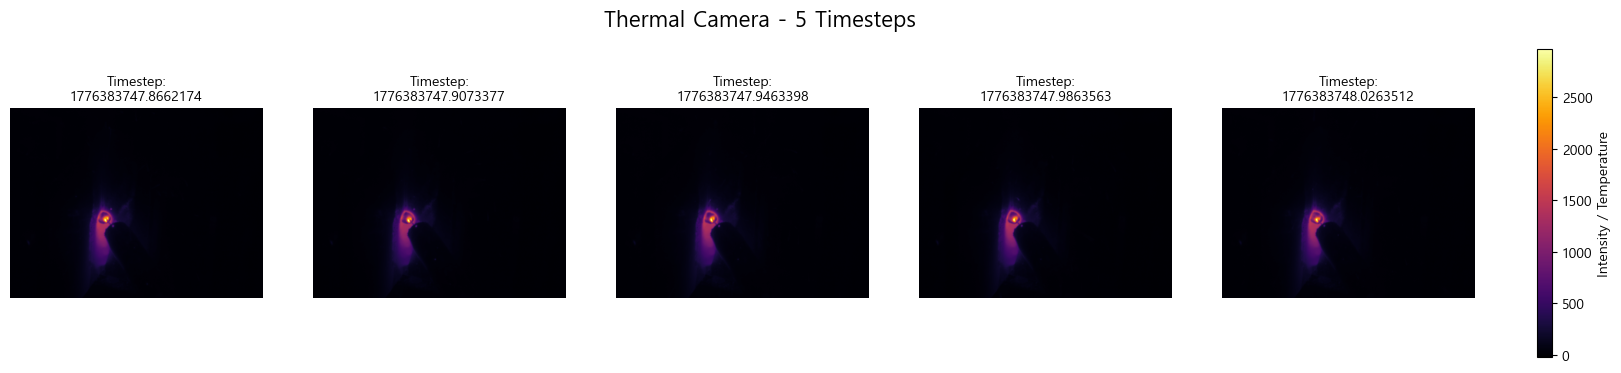

In [5]:
# 3. 딕셔너리에서 5개의 키(타임스텝) 추출
keys = list(data.keys())

# 옵션 A: 처음 5개의 연속된 타임스텝 보기
sample_keys = keys[1050:1055] 

print("샘플 정보")
print(f"샘플 크기: {np.shape(data[sample_keys[0]])}")

# 옵션 B: 전체 시간대에서 일정한 간격으로 5개 뽑아서 보기 (변화 확인에 좋음)
# sample_keys = [keys[i] for i in range(0, len(keys), len(keys)//5)][:5]

# 4. 5개의 타임스텝 시각화
fig, axes = plt.subplots(1, 5, figsize=(20, 4)) # 1행 5열의 도화지 생성

for i, key in enumerate(sample_keys):
    frame = data[key] # 해당 타임스텝의 이미지 데이터 가져오기
    
    # 만약 딕셔너리의 value가 배열이 아니라 또 다른 dict라면, 
    # frame = data[key]['image'] 처럼 실제 데이터가 있는 곳까지 접근해야 할 수 있습니다.
    
    # 이미지 시각화
    im = axes[i].imshow(frame, cmap='inferno')
    axes[i].set_title(f'Timestep:\n{key}', fontsize=10)
    axes[i].axis('off') # 깔끔하게 축 숨기기

# 전체 그림에 대한 공통 컬러바 추가
fig.colorbar(im, ax=axes.ravel().tolist(), label='Intensity / Temperature', fraction=0.015, pad=0.04)

plt.suptitle('Thermal Camera - 5 Timesteps', fontsize=16)
plt.show()

In [23]:
frames = npy_data

# 2. 영상 설정
fps = 30
height, width = frames.shape[1], frames.shape[2]  # 320, 426
output_path = 'output_thermal_TF033.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# 3. 온도 범위 설정 (전체 기준 or 고정값)
t_min = frames.min()
t_max = frames.max()
# t_min, t_max = 0, 3000  # 고정 범위 원할 경우 이 줄 사용

# 4. 프레임 변환 및 저장
for i, frame in enumerate(frames):
    # 0~255로 정규화
    normalized = np.clip((frame - t_min) / (t_max - t_min), 0, 1)
    gray = (normalized * 255).astype(np.uint8)

    # 컬러맵 적용 (열화상 느낌: INFERNO / JET / HOT 등)
    colored = cv2.applyColorMap(gray, cv2.COLORMAP_INFERNO)

    out.write(colored)

    if i % 100 == 0:
        print(f"Processing: {i}/{len(frames)} frames ({i/len(frames)*100:.1f}%)")

out.release()
print(f"저장 완료: {output_path}")

Processing: 0/3296 frames (0.0%)
Processing: 100/3296 frames (3.0%)
Processing: 200/3296 frames (6.1%)
Processing: 300/3296 frames (9.1%)
Processing: 400/3296 frames (12.1%)
Processing: 500/3296 frames (15.2%)
Processing: 600/3296 frames (18.2%)
Processing: 700/3296 frames (21.2%)
Processing: 800/3296 frames (24.3%)
Processing: 900/3296 frames (27.3%)
Processing: 1000/3296 frames (30.3%)
Processing: 1100/3296 frames (33.4%)
Processing: 1200/3296 frames (36.4%)
Processing: 1300/3296 frames (39.4%)
Processing: 1400/3296 frames (42.5%)
Processing: 1500/3296 frames (45.5%)
Processing: 1600/3296 frames (48.5%)
Processing: 1700/3296 frames (51.6%)
Processing: 1800/3296 frames (54.6%)
Processing: 1900/3296 frames (57.6%)
Processing: 2000/3296 frames (60.7%)
Processing: 2100/3296 frames (63.7%)
Processing: 2200/3296 frames (66.7%)
Processing: 2300/3296 frames (69.8%)
Processing: 2400/3296 frames (72.8%)
Processing: 2500/3296 frames (75.8%)
Processing: 2600/3296 frames (78.9%)
Processing: 2700/

In [7]:
# 3. 전체 데이터 중 가장 온도가 높은 프레임 찾기
best_key = None
global_min_temp = np.inf

for key, frame in data.items():
    current_min = np.min(frame)
    if current_min < global_min_temp:
        global_min_temp = current_min
        best_key = key

print(f"가장 온도가 낮은 프레임 키: {best_key} | 최소 온도: {global_min_temp:.1f}")

가장 온도가 낮은 프레임 키: 1776383718.0272923 | 최소 온도: -52.9


In [31]:
30*60

1800

가장 온도가 높은 프레임 키: 1776383722.9478 | 최대 온도: 3160.0
115 166 95 125 151 181


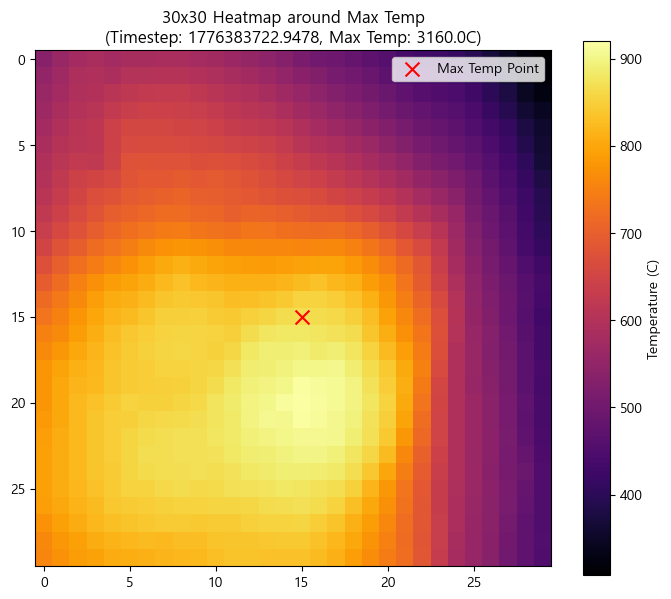

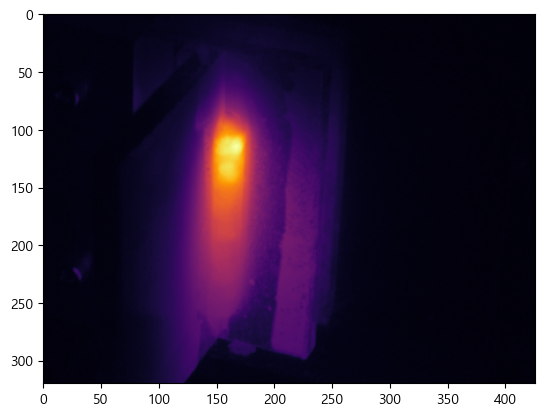

In [50]:
# 3. 전체 데이터 중 가장 온도가 높은 프레임 찾기
best_key = None
global_max_temp = -np.inf

for key, frame in data.items():
    current_max = np.max(frame)
    if current_max > global_max_temp:
        global_max_temp = current_max
        best_key = key


print(f"가장 온도가 높은 프레임 키: {best_key} | 최대 온도: {global_max_temp:.1f}")

# target_frame = data[best_key]
target_frame = data[keys[2000]]  # 테스트용으로 임의의 프레임을 사용 (실제론 best_key로 해야 함)


# 4. 최고 온도 픽셀의 좌표 (y, x) 찾기
# np.argmax는 배열을 1차원으로 폈을 때의 인덱스를 반환하므로, unravel_index로 2D 좌표로 변환합니다.
max_y, max_x = np.unravel_index(np.argmax(target_frame), target_frame.shape)

# 5. 30x30 픽셀 영역 자르기 위한 경계 좌표 계산 (반지름 15픽셀)
crop_height = 30
crop_width = 30

y1 = max_y - crop_height // 2 - 5
y2 = max_y + crop_height // 2 - 5 
x1 = max_x - crop_width // 2
x2 = max_x + crop_width // 2

# 이미지 범위를 벗어나는 경우 (가장자리 처리)
if y1 < 0:
    y2 -= y1; y1 = 0
if y2 > target_frame.shape[0]:
    y1 -= (y2 - target_frame.shape[0]); y2 = target_frame.shape[0]
if x1 < 0:
    x2 -= x1; x1 = 0
if x2 > target_frame.shape[1]:
    x1 -= (x2 - target_frame.shape[1]); x2 = target_frame.shape[1]

# 6. 영역 크롭
cropped_heatmap = target_frame[y1:y2, x1:x2]

print(max_y, max_x, y1, y2, x1, x2)

# 크롭된 이미지 내에서의 최고점 상대 좌표 계산 (X 표시용)
relative_max_y = max_y - y1 - 5
relative_max_x = max_x - x1

# 7. 히트맵 시각화
plt.figure(figsize=(7, 6))
# 1000도 이상의 원본 데이터 값을 있는 그대로 띄워줍니다.
im = plt.imshow(cropped_heatmap, cmap='inferno')

# 최고점 위치에 빨간색 X 표시
plt.scatter([relative_max_x], [relative_max_y], color='red', marker='x', s=100, label='Max Temp Point')

plt.colorbar(im, label='Temperature (C)')
plt.title(f"30x30 Heatmap around Max Temp\n(Timestep: {best_key}, Max Temp: {global_max_temp:.1f}C)")
plt.legend(loc='upper right')
plt.axis('on') # 픽셀 좌표계를 보기 위해 축을 켭니다.

plt.tight_layout()
plt.show()

plt.imshow(target_frame, cmap='inferno')
plt.show()

In [56]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from concurrent.futures import ThreadPoolExecutor, as_completed
import multiprocessing

# ---- 설정 ----
output_dir = "frame_images"
os.makedirs(output_dir, exist_ok=True)

start_frame = 376
end_frame = 2200
NUM_WORKERS = max(1, multiprocessing.cpu_count() - 1)

# 전체 온도 범위
global_min = min(np.min(f) for f in data.values())
global_max = max(np.max(f) for f in data.values())

print(f"온도 범위: {global_min:.1f} ~ {global_max:.1f}")
print(f"저장 프레임: {start_frame}~{end_frame} | workers: {NUM_WORKERS}")


def process_frame(args):
    idx, key, frame = args

    max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)
    max_temp = frame[max_y, max_x]

    y1 = max_y - 20; y2 = max_y + 10
    x1 = max_x - 15; x2 = max_x + 15
    H, W = frame.shape
    if y1 < 0:   y2 -= y1;        y1 = 0
    if y2 > H:   y1 -= (y2 - H);  y2 = H
    if x1 < 0:   x2 -= x1;        x1 = 0
    if x2 > W:   x1 -= (x2 - W);  x2 = W

    cropped = frame[y1:y2, x1:x2]
    rel_y = max_y - y1 - 5
    rel_x = max_x - x1

    vkw = dict(cmap='inferno', vmin=global_min, vmax=global_max)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                             gridspec_kw={'wspace': 0.05})

    ax1 = axes[0]
    ax1.imshow(frame, **vkw, aspect='auto')
    ax1.add_patch(patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=1.2, edgecolor='cyan', facecolor='none'))
    ax1.scatter([max_x], [max_y], c='red', marker='x', s=60, linewidths=1)
    ax1.set_title(f"#{idx}  {max_temp:.0f}°C", fontsize=8, pad=2)
    ax1.axis('off')

    ax2 = axes[1]
    im = ax2.imshow(cropped, **vkw, aspect='auto')
    ax2.scatter([rel_x], [rel_y], c='red', marker='x', s=60, linewidths=1)
    ax2.set_title("crop", fontsize=8, pad=2)
    ax2.axis('off')

    cb = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
    cb.ax.tick_params(labelsize=6)
    cb.set_label('°C', fontsize=7)

    fig.suptitle(f"Frame {idx}", fontsize=9, y=1.01)

    save_path = os.path.join(output_dir, f"f{idx:04d}.jpg")
    fig.savefig(save_path, dpi=80, format='jpeg',
                bbox_inches='tight',
                pil_kwargs={'quality': 75, 'optimize': True})
    plt.close(fig)
    return idx


# ---- 실행 ----
import matplotlib
matplotlib.use('Agg')  # GUI 없는 백엔드 (스레드 안전)

args_list = [
    (idx, keys[idx], data[keys[idx]])
    for idx in range(start_frame, end_frame + 1)
]

done = 0
total = len(args_list)

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {executor.submit(process_frame, a): a[0] for a in args_list}
    for future in as_completed(futures):
        try:
            future.result()
        except Exception as e:
            print(f"  ⚠️ 오류: {e}")
        done += 1
        if done % 200 == 0 or done == total:
            print(f"  {done}/{total} ({done/total*100:.1f}%)")

print(f"\n✅ 완료 → {output_dir}/  ({total}장)")

온도 범위: -52.9 ~ 3160.0
저장 프레임: 376~2200 | workers: 15
  200/1825 (11.0%)
  400/1825 (21.9%)
  600/1825 (32.9%)
  800/1825 (43.8%)
  1000/1825 (54.8%)
  1200/1825 (65.8%)
  1400/1825 (76.7%)
  1600/1825 (87.7%)
  1800/1825 (98.6%)
  1825/1825 (100.0%)

✅ 완료 → frame_images/  (1825장)


In [10]:
# # 격자 인덱스 (플롯용)
# xi = np.arange(50)
# yi = np.arange(50)
# XI, YI = np.meshgrid(xi, yi)

# # ── 시각화 ───────────────────────────────────────────────────
# fig = plt.figure(figsize=(20, 16))
# fig.patch.set_facecolor('#0f0f1a')

# # 1. Surface Plot
# ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# surf = ax1.plot_surface(XI, YI, cropped_heatmap, cmap='plasma', alpha=0.95,
#                          linewidth=0, antialiased=True)
# ax1.set_facecolor('#0f0f1a')
# ax1.set_title('Surface Plot', color='white', fontsize=13, pad=10)
# ax1.tick_params(colors='gray', labelsize=7)
# for pane in [ax1.xaxis.pane, ax1.yaxis.pane, ax1.zaxis.pane]:
#     pane.fill = False
#     pane.set_edgecolor('#333355')
# fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.1).ax.yaxis.set_tick_params(color='white', labelcolor='white')

# # 2. Wireframe Plot
# ax2 = fig.add_subplot(2, 2, 2, projection='3d')
# ax2.plot_wireframe(XI, YI, cropped_heatmap, cmap='cool',
#                    linewidth=0.5, rstride=2, cstride=2)
# ax2.set_facecolor('#0f0f1a')
# ax2.set_title('Wireframe Plot', color='white', fontsize=13, pad=10)
# ax2.tick_params(colors='gray', labelsize=7)
# for pane in [ax2.xaxis.pane, ax2.yaxis.pane, ax2.zaxis.pane]:
#     pane.fill = False
#     pane.set_edgecolor('#333355')

# # 3. Contour 3D Plot
# ax3 = fig.add_subplot(2, 2, 3, projection='3d')
# ax3.contourf(XI, YI, cropped_heatmap, zdir='z', offset=25,  cmap='viridis', levels=20, alpha=0.85)
# ax3.contourf(XI, YI, cropped_heatmap, zdir='x', offset=0,   cmap='viridis', levels=10, alpha=0.5)
# ax3.contourf(XI, YI, cropped_heatmap, zdir='y', offset=49,  cmap='viridis', levels=10, alpha=0.5)
# ax3.set_facecolor('#0f0f1a')
# ax3.set_title('Contour 3D Plot', color='white', fontsize=13, pad=10)
# ax3.tick_params(colors='gray', labelsize=7)
# for pane in [ax3.xaxis.pane, ax3.yaxis.pane, ax3.zaxis.pane]:
#     pane.fill = False
#     pane.set_edgecolor('#333355')

# # 4. Scatter 3D Plot
# ax4 = fig.add_subplot(2, 2, 4, projection='3d')
# sample_idx = np.random.choice(50 * 50, size=800, replace=False)
# sc = ax4.scatter(XI.flatten()[sample_idx],
#                  YI.flatten()[sample_idx],
#                  cropped_heatmap.flatten()[sample_idx],
#                  c=cropped_heatmap.flatten()[sample_idx],
#                  cmap='inferno', s=15, alpha=0.75, edgecolors='none')
# ax4.set_facecolor('#0f0f1a')
# ax4.set_title('Scatter 3D Plot (샘플 800개)', color='white', fontsize=13, pad=10)
# ax4.tick_params(colors='gray', labelsize=7)
# for pane in [ax4.xaxis.pane, ax4.yaxis.pane, ax4.zaxis.pane]:
#     pane.fill = False
#     pane.set_edgecolor('#333355')
# fig.colorbar(sc, ax=ax4, shrink=0.5, pad=0.1).ax.yaxis.set_tick_params(color='white', labelcolor='white')

# for ax in [ax1, ax2, ax3, ax4]:
#     ax.set_xlabel('X', color='gray', fontsize=9)
#     ax.set_ylabel('Y', color='gray', fontsize=9)
#     ax.set_zlabel('Value', color='gray', fontsize=9)

# fig.suptitle('50×50 Gaussian Distribution — Center Peak\n(range: 25 ~ 2500)',
#              color='white', fontsize=16, fontweight='bold', y=0.98)

# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('3d_gaussian.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
# plt.show()
# print(f"중앙값: {cropped_heatmap[25, 25]:.1f}  |  최솟값: {cropped_heatmap.min():.1f}  |  최댓값: {cropped_heatmap.max():.1f}")

In [ ]:
def make_crop_heatmaps(data: dict, crop_height: int = 50, crop_width: int = 50, min_temp: float = 800.0) -> tuple[np.ndarray, list]:
    """
    최고 온도가 min_temp 이상인 프레임만 최고 온도 픽셀 중심으로 crop_height x crop_width 크롭.

    Parameters
    ----------
    data      : {key: 2D ndarray} 형태의 프레임 딕셔너리
    crop_height : 크롭 높이, 기본값 50
    crop_width  : 크롭 너비, 기본값 50
    min_temp  : 최고 온도 필터 임계값, 기본값 800.0

    Returns
    -------
    crops   : ndarray, shape = (N, crop_height, crop_width)
    indices : list of (frame_index, key) — 저장된 프레임의 순번과 원본 키
    """

    # 5. 30x30 픽셀 영역 자르기 위한 경계 좌표 계산 (반지름 15픽셀)
    crop_height = 30
    crop_width = 30

    crops = []
    indices = []  # (frame_index, key) 튜플 리스트

    for frame_index, (key, frame) in enumerate(data.items()):
        # 최고 온도가 임계값 미만이면 스킵
        if np.max(frame) < min_temp:
            continue

        h, w = frame.shape

        # 최고 온도 픽셀 좌표
        max_y, max_x = np.unravel_index(np.argmax(frame), frame.shape)

        # 크롭 경계 계산
        y1 = max_y - crop_height // 2 - 5
        y2 = max_y + crop_height // 2 - 5 
        x1 = max_x - crop_width // 2
        x2 = max_x + crop_width // 2

        # 가장자리 보정
        if y1 < 0:
            y2 -= y1;  y1 = 0
        if y2 > h:
            y1 -= (y2 - h);  y2 = h
        if x1 < 0:
            x2 -= x1;  x1 = 0
        if x2 > w:
            x1 -= (x2 - w);  x2 = w

        crops.append(frame[y1:y2, x1:x2])
        indices.append((frame_index, key))

    if not crops:
        raise ValueError(f"최고 온도가 {min_temp} 이상인 프레임이 없습니다.")

    return np.stack(crops, axis=0), np.array(indices)


# 사용 예시
crop_heatmaps, indices = make_crop_heatmaps(data, crop_height=14, crop_width=22, min_temp=800.0)

print(f"저장된 프레임 수: {len(indices)} / 전체 {len(data)}")
print(f"ndarray shape  : {crop_heatmaps.shape}")
print()
print("[ 저장된 프레임 인덱스 정보 ]")
for crop_idx, (frame_index, key) in enumerate(indices):
    print(f"  crops[{crop_idx:>4}] ← data 순번 {frame_index:>5} | key: {key}")

np.save(f'crop_heatmap_{TF_case}.npy', crop_heatmaps)

저장된 프레임 수: 1684 / 전체 3296
ndarray shape  : (1684, 30, 30)

[ 저장된 프레임 인덱스 정보 ]
  crops[   0] ← data 순번 376.0 | key: 1776383720.907032
  crops[   1] ← data 순번 377.0 | key: 1776383720.9473104
  crops[   2] ← data 순번 378.0 | key: 1776383720.9877384
  crops[   3] ← data 순번 379.0 | key: 1776383721.026841
  crops[   4] ← data 순번 380.0 | key: 1776383721.0669005
  crops[   5] ← data 순번 381.0 | key: 1776383721.1068573
  crops[   6] ← data 순번 382.0 | key: 1776383721.1466007
  crops[   7] ← data 순번 383.0 | key: 1776383721.1875315
  crops[   8] ← data 순번 384.0 | key: 1776383721.2276669
  crops[   9] ← data 순번 385.0 | key: 1776383721.2671585
  crops[  10] ← data 순번 386.0 | key: 1776383721.3063874
  crops[  11] ← data 순번 387.0 | key: 1776383721.3467193
  crops[  12] ← data 순번 388.0 | key: 1776383721.3864133
  crops[  13] ← data 순번 389.0 | key: 1776383721.426409
  crops[  14] ← data 순번 390.0 | key: 1776383721.466409
  crops[  15] ← data 순번 391.0 | key: 1776383721.5068638
  crops[  16] ← data 순번 392.0 

In [20]:
len(keys)

3296

In [14]:
np.shape(crop_heatmaps)

(1684, 14, 22)

In [15]:
np.all(np.diff(indices[:, 0]) == 1)
# True이면 저장된 프레임들이 원본 데이터에서 순차적으로 존재한다는 의미입니다.

np.True_

[   0   16   72  376  377  840  888 1208 1405 1683]
(1684, 14, 22)


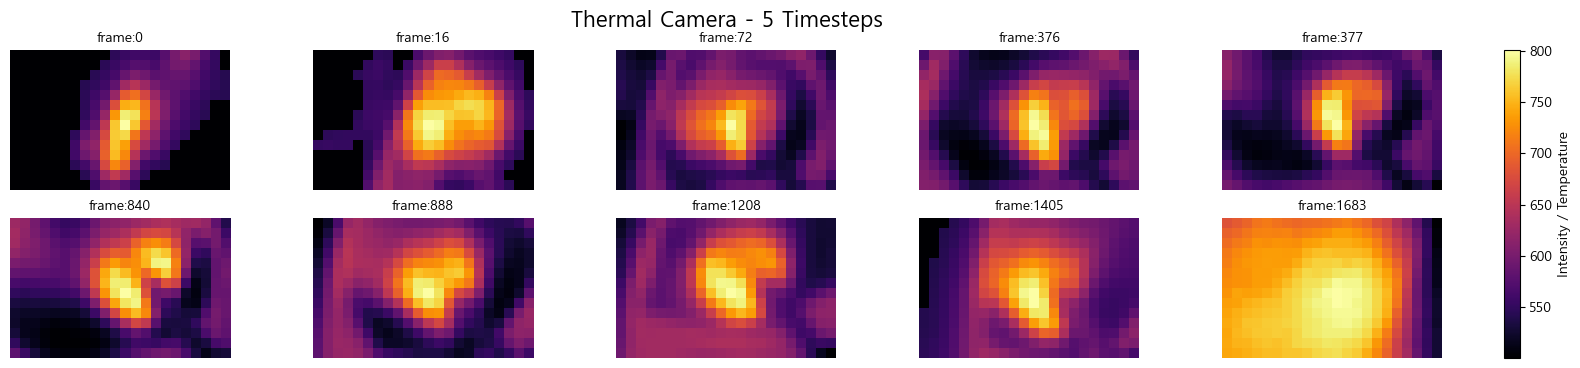

In [16]:
idx = [0]
idx = np.append(idx, np.sort(np.random.randint(0, crop_heatmaps.shape[0], 8)))
idx = np.append(idx, crop_heatmaps.shape[0]-1)
print(idx)

print(crop_heatmaps.shape)

clip_heatmaps = np.where(crop_heatmaps < 400, 0.0, crop_heatmaps)
# clip_heatmaps = np.clip(clip_heatmaps, None, 2500)

fig, axes = plt.subplots(2, 5, figsize=(20, 4)) # 2행 5열의 도화지 생성

for i, j in enumerate(idx):
    im = axes.flat[i].imshow(clip_heatmaps[j], cmap='inferno')
    axes.flat[i].set_title(f'frame:{j}', fontsize=10)
    axes.flat[i].axis('off')

# 전체 그림에 대한 공통 컬러바 추가
fig.colorbar(im, ax=axes.ravel().tolist(), label='Intensity / Temperature', fraction=0.015, pad=0.04)

plt.suptitle('Thermal Camera - 5 Timesteps', fontsize=16)
plt.show()

In [17]:
crop_heatmaps.shape

(1684, 14, 22)

In [18]:
np.save(f"crop_heatmaps_{TF_case}.npy", crop_heatmaps)